# Exploring EW4 data - GPM IMERG
This notebook explore the GPM IMERG dataset, including loading in PyEarthTools.

This dataset is a subset of the [NASA Integrated Multi-satellite Retrieval (IMERG)](https://gpm.nasa.gov/data/imerg) data for Global Precipitation Measurement (GPM). This subset has the following extents:
- Temporal Extent: April to September 2025
- Spatial Extent
  - Latitude 0N to 20N
  - Longitude 27W to 20E


### Import libraries

In [65]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pathlib
import datetime
import functools
import math

In [3]:
import numpy

In [4]:
import xarray

In [5]:
import matplotlib
import cartopy.crs

In [6]:
import site_archive_jasmin

ROOT_DIRECTORIES: {'ERA5lowres': '/gws/nopw/j04/mohc_shared/dscop/weatherbench/5.625deg/', 'MOGLOBAL': '/gws/nopw/j04/mohc_shared//dscop/mo_pet_site_archive/mo_global/', 'MOUKV': '/gws/nopw/j04/mohc_shared//dscop/mo_pet_site_archive/mo_ukv/', 'Himawari': '/gws/ssde/j25a/mmh_storage/theme3/rv74_himawari', 'HimawariChannels': '/gws/ssde/j25a/mmh_storage/theme3/ra22_himawari', 'Rainfields3': '/gws/ssde/j25a/mmh_storage/theme3/rq0Radar', 'ew4_imerg_precip': '/gws/nopw/j04/ew4energy/imerg_2025_summer', 'ew4_merra2_meteo': '/gws/nopw/j04/ew4energy/West_Africa_Merra-2_2015-2025_meteo', 'ew4_merra2_aero': '/gws/nopw/j04/ew4energy/West_Africa_Merra-2_2015-2025_aerosols/3d', 'ew4_mtg_li': '/gws/nopw/j04/ew4energy/MTG_LI/', 'ew4_era5': '/gws/nopw/j04/ew4energy/ERA5/hourly/pl_levels'}


In [7]:
import pyearthtools

In [8]:
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe

In [9]:
from pyearthtools.data import Petdt, TimeDelta
from pyearthtools.data.exceptions import DataNotFoundError
from pyearthtools.data.indexes import ArchiveIndex, decorators
from pyearthtools.data.transforms import Transform, TransformCollection
from pyearthtools.data.archive import register_archive


In [10]:
from site_archive_jasmin.utilities import (
    cached_exists,
    cached_iterdir,
)  # Could these be moved into a generic module?


In [11]:
import torch

## Explore the data in the dataset
Lets start by looking at a sample data file, before demonstrating loading the data in pyearthtools

In [12]:
ew4_gws_dir = pathlib.Path('/gws/nopw/j04/ew4energy/')
imerg_ew4_dir = ew4_gws_dir / 'imerg_2025_summer'


In [13]:
def get_imerg_path(start_dt, time_delta, fname_template, data_dir):
    day_minutes = start_dt.hour * 60 + start_dt.minute
    date_str = '{dt.year:04d}{dt.month:02d}{dt.day:02d}'.format(dt=start_dt)
    time_template = '{dt.hour:02d}{dt.minute:02d}{dt.second:02d}'
    start_time = time_template.format(dt=start_dt)
    end_time = time_template.format(dt=start_dt+time_delta-datetime.timedelta(seconds=1))
    imerg_path = data_dir / fname_template.format(date_str=date_str,
                                              start_time=start_time,
                                              end_time=end_time,
                                                  day_minutes=day_minutes,
                                             )
    return imerg_path


In [14]:
imerg_fname_template = '3B-HHR-E.MS.MRG.3IMERG.{date_str}-S{start_time}-E{end_time}.{day_minutes:04d}.V07B.HDF5.SUB.nc4'

In [15]:
start_dt = datetime.datetime(2025,5,1,0,0)
end_dt = datetime.datetime(2025,6,1,0,0)
time_delta=datetime.timedelta(minutes=30)

In [16]:
num_files = int((end_dt - start_dt) / time_delta)

In [17]:
num_files

1488

In [18]:
imerg_filelist = [
    get_imerg_path(start_dt + (time_delta * time_ix),
                   time_delta,
                   imerg_fname_template,
                   imerg_ew4_dir
                  )
    for time_ix in range(num_files) ]


In [19]:
ew4_imerge_sample_ds = xarray.open_mfdataset(imerg_filelist)

In [20]:
ew4_imerge_sample_ds['precipitation']


<xarray.DataArray 'precipitation' (time: 1488, lon: 469, lat: 202)> Size: 564MB
dask.array<concatenate, shape=(1488, 469, 202), dtype=float32, chunksize=(1, 469, 139), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 12kB 2025-05-01 ... 2025-05-31T23:30:00
  * lon      (lon) float32 2kB -27.05 -26.95 -26.85 -26.75 ... 19.55 19.65 19.75
  * lat      (lat) float32 808B 0.05 0.15 0.25 0.35 ... 19.85 19.95 20.05 20.15
Attributes:
    units:             mm/hr
    DimensionNames:    time,lon,lat
    Units:             mm/hr
    CodeMissingValue:  -9999.9
    LongName:          \nComplete merged microwave-infrared (gauge-adjusted)\...

In [21]:
float(min(ew4_imerge_sample_ds['lat'])), float(max(ew4_imerge_sample_ds['lat'])), float(min(ew4_imerge_sample_ds['lon'])), float(max(ew4_imerge_sample_ds['lon']))

(0.04999999701976776, 20.149999618530273, -27.049999237060547, 19.75)

In [22]:
precip_plot_bins = [1e-3,0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0]

(array([3339399., 1379693., 1557787., 2167344., 1963238., 1841467.,
        1621064.,  948631.,  355868.,   94591.]),
 array([1.0e-03, 5.0e-02, 1.0e-01, 2.0e-01, 5.0e-01, 1.0e+00, 2.0e+00,
        4.0e+00, 8.0e+00, 1.6e+01, 3.2e+01]),
 <BarContainer object of 10 artists>)

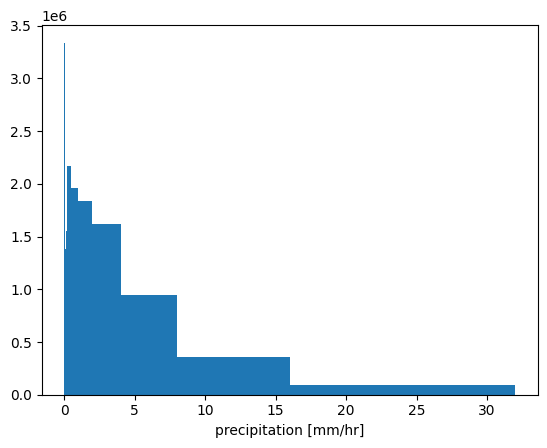

In [23]:
ew4_imerge_sample_ds['precipitation'].plot.hist(bins=precip_plot_bins)


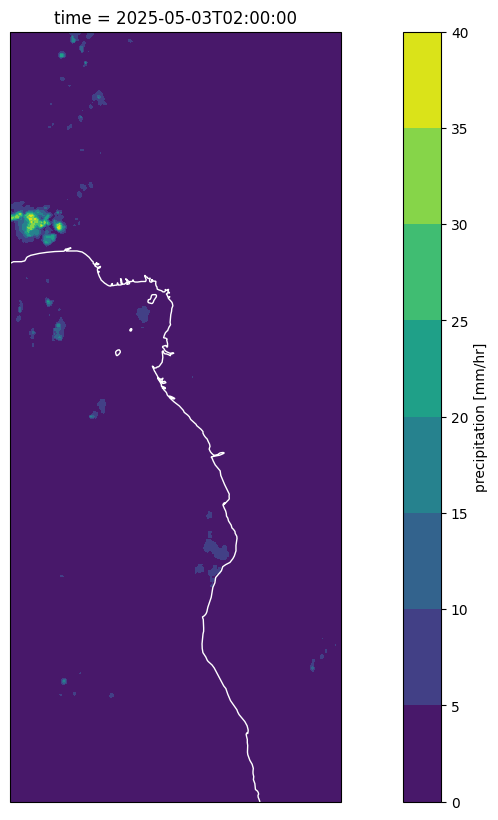

In [24]:
fig1 = matplotlib.pyplot.figure(figsize=(16,10))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
ew4_imerge_sample_ds['precipitation'][100].plot.contourf(ax=ax1)
ax1.coastlines(color='w')

## Loading the Data in PyEarthTools
Now we will load the data through the PyEarthTools data accessor. This is a class that has been created which how to access the data. For a dataset like this which is stored as files on disk, it specifries which files to load. Data could be loaded through other mechanisms though, for example it could be load from a database, through a web api, from a tape archive,  from a cloud-based object store or many other mechanisms.

In [25]:
ew4_imerg_accessor = site_archive_jasmin.Ew4Imerg('2025-04-01 00:00', '2025-10-01 00:00')

In [26]:
ew4_imerg_accessor

Ew4Imerg
	Description                    GPM IMERG - EW4Energy project 
		 range                          '2025-04-01 to 2025-09-30'
		 Documentation                  'https://gpm.nasa.gov/data/imerg'


	Initialisation                 
		 end                            '2025-10-01 00:00'
		 start                          '2025-04-01 00:00'
	Transforms                     
		 StandardCoordinateNames        {'latitude': "['lat', 'Latitude', 'yt_ocean', 'yt']", 'longitude': "['lon', 'Longitude', 'xt_ocean', 'xt']", 'replacement_dictionary': 'None', 'time': "['Time']"}

In [27]:
ew4_imerg_accessor['2025-05-23 03:00']

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


<xarray.Dataset> Size: 382kB
Dimensions:        (time: 1, longitude: 469, latitude: 202)
Coordinates:
  * time           (time) datetime64[ns] 8B 2025-05-23T03:00:00
  * longitude      (longitude) float32 2kB -27.05 -26.95 -26.85 ... 19.65 19.75
  * latitude       (latitude) float32 808B 0.05 0.15 0.25 ... 19.95 20.05 20.15
Data variables:
    precipitation  (time, longitude, latitude) float32 379kB dask.array<chunksize=(1, 469, 202), meta=np.ndarray>
Attributes:
    CDI:                                    Climate Data Interface version 1....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
    InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250523-S...
    history_L34RS:                          'Created by L34RS v1.4.4 @ NASA G...
    CDO:                                    Climate Data Operators version 1....

In [28]:
ew4_imerg_accessor['2025-05-23 13']



<xarray.Dataset> Size: 382kB
Dimensions:        (time: 1, longitude: 469, latitude: 202)
Coordinates:
  * time           (time) datetime64[ns] 8B 2025-05-23T13:00:00
  * longitude      (longitude) float32 2kB -27.05 -26.95 -26.85 ... 19.65 19.75
  * latitude       (latitude) float32 808B 0.05 0.15 0.25 ... 19.95 20.05 20.15
Data variables:
    precipitation  (time, longitude, latitude) float32 379kB dask.array<chunksize=(1, 469, 202), meta=np.ndarray>
Attributes:
    CDI:                                    Climate Data Interface version 1....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
    InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250523-S...
    history_L34RS:                          'Created by L34RS v1.4.4 @ NASA G...
    CDO:                                    Climate Data Operators version 1....

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


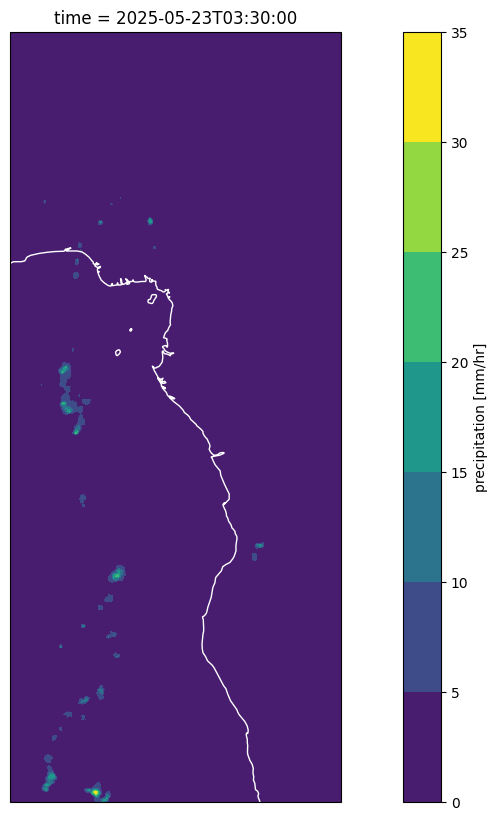

In [29]:
fig1 = matplotlib.pyplot.figure(figsize=(16,10))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
ew4_imerg_accessor['2025-05-23 03:30']['precipitation'][0].plot.contourf(ax=ax1)

ax1.coastlines(color='w')


To demonstrate working with just a region of interest, we will select some data roughly corresponding to Ghana. The bounds have been tweaked a little so we can an array of a power of 2 size (64x64) as this is conveneient for working with a convolutional neural network.

In [30]:
ghana_extents = {
    'latitude': (4.7,11.1),
    'longitude': (-3.5, 2.9),
}


In [31]:
ghana_pet_box = (ghana_extents['latitude'][0],
                 ghana_extents['latitude'][1],
                 ghana_extents['longitude'][0],
                 ghana_extents['longitude'][1],
                )

In [32]:
ew4_imerg_pipeline = petpipe.Pipeline(
    ew4_imerg_accessor,
    petdata.transform.region.Bounding(*ghana_pet_box),  
    petpipe.modifications.TemporalWindow(prior_indexes=[0,], posterior_indexes=[0,], timedelta=TimeDelta('30 minutes')),
    iterator=petpipe.iterators.DateRange('20250501T00', '20250511T00', interval='30 minutes'), 
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)


In [33]:
ew4_imerg_pipeline['20250503T0700']

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


([<xarray.Dataset> Size: 17kB
  Dimensions:        (time: 1, longitude: 64, latitude: 64)
  Coordinates:
    * time           (time) datetime64[ns] 8B 2025-05-03T07:00:00
    * longitude      (longitude) float32 256B -3.45 -3.35 -3.25 ... 2.65 2.75 2.85
    * latitude       (latitude) float32 256B 4.75 4.85 4.95 ... 10.85 10.95 11.05
  Data variables:
      precipitation  (time, longitude, latitude) float32 16kB dask.array<chunksize=(1, 64, 64), meta=np.ndarray>
  Attributes:
      CDI:                                    Climate Data Interface version 1....
      Conventions:                            CF-1.6
      Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
      Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
      Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
      InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250503-S...
      history_L34RS:                          'Crea

In [34]:
ew4_imerg_iter = iter(ew4_imerg_pipeline)

In [35]:
next(ew4_imerg_iter)

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


([<xarray.Dataset> Size: 17kB
  Dimensions:        (time: 1, longitude: 64, latitude: 64)
  Coordinates:
    * time           (time) datetime64[ns] 8B 2025-05-01
    * longitude      (longitude) float32 256B -3.45 -3.35 -3.25 ... 2.65 2.75 2.85
    * latitude       (latitude) float32 256B 4.75 4.85 4.95 ... 10.85 10.95 11.05
  Data variables:
      precipitation  (time, longitude, latitude) float32 16kB dask.array<chunksize=(1, 64, 64), meta=np.ndarray>
  Attributes:
      CDI:                                    Climate Data Interface version 1....
      Conventions:                            CF-1.6
      Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
      Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
      Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
      InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250501-S...
      history_L34RS:                          'Created by L3

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


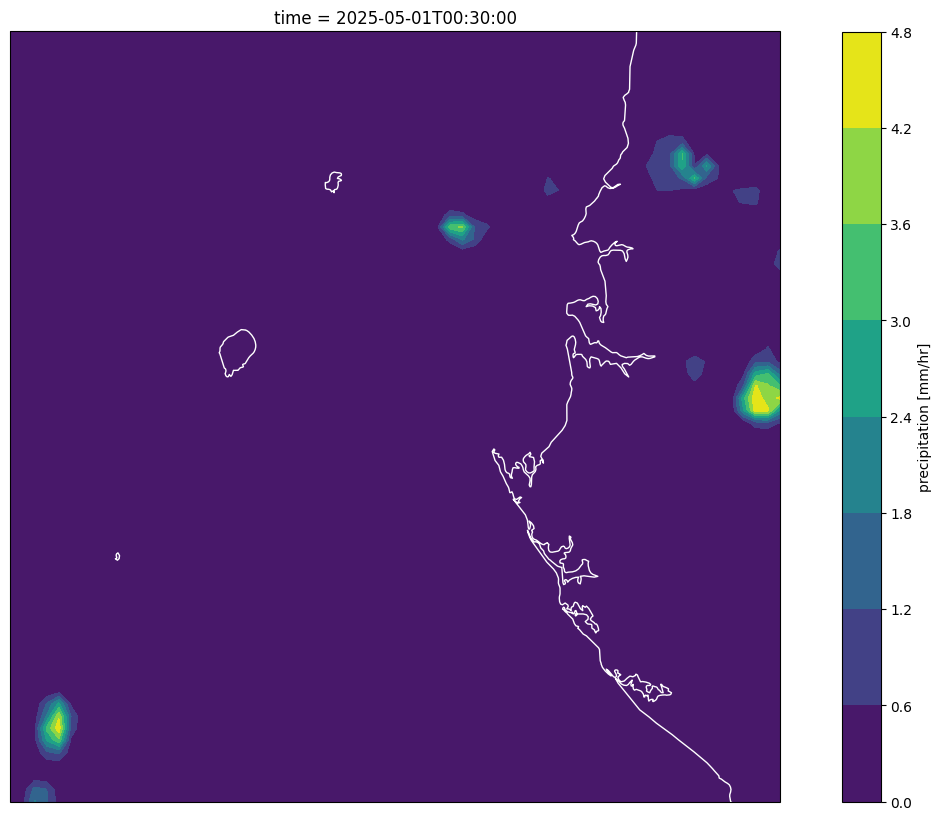

In [36]:
fig1 = matplotlib.pyplot.figure(figsize=(16,10))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
next(ew4_imerg_iter)[0][0]['precipitation'][0].plot.contourf(ax=ax1)
ax1.coastlines(color='w')


In [37]:
next(ew4_imerg_iter), next(ew4_imerg_iter),

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


(([<xarray.Dataset> Size: 17kB
   Dimensions:        (time: 1, longitude: 64, latitude: 64)
   Coordinates:
     * time           (time) datetime64[ns] 8B 2025-05-01T01:00:00
     * longitude      (longitude) float32 256B -3.45 -3.35 -3.25 ... 2.65 2.75 2.85
     * latitude       (latitude) float32 256B 4.75 4.85 4.95 ... 10.85 10.95 11.05
   Data variables:
       precipitation  (time, longitude, latitude) float32 16kB dask.array<chunksize=(1, 64, 64), meta=np.ndarray>
   Attributes:
       CDI:                                    Climate Data Interface version 1....
       Conventions:                            CF-1.6
       Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
       Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
       Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
       InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250501-S...
       history_L34RS:               

## Train an ML model
To demonstrate how we can use this data in a machine learning training pipeline, we will show a simple autoencoder

In [38]:
ew4_imerg_prep = petpipe.Pipeline(
    ew4_imerg_accessor,
    petdata.transform.region.Bounding(*ghana_pet_box),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)

In [39]:
ew4_imerg_ml = petpipe.Pipeline(
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
)


In [40]:
(ew4_imerg_prep | ew4_imerg_ml)['2025-07-05 16:00']

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


array([[[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]]],
      shape=(1, 1, 64, 64), dtype=float32)

In [41]:
train_range = petpipe.Pipeline(
    petpipe.modifications.TemporalWindow(prior_indexes=[0,], posterior_indexes=[0,], timedelta=TimeDelta('30 minutes')),
    iterator=petpipe.iterators.DateRange('20250501T00', '20250701T00', interval='30 minutes').randomise(), 
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)
val_range = petpipe.Pipeline(
    petpipe.modifications.TemporalWindow(prior_indexes=[0,], posterior_indexes=[0,], timedelta=TimeDelta('30 minutes')),
    iterator=petpipe.iterators.DateRange('20250701T00', '20250801T00', interval='30 minutes'), 
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)

Calculated indexes


In [42]:
ew4_imerg_train_pipe = ew4_imerg_prep | ew4_imerg_ml | train_range
ew4_imerg_val_pipe = ew4_imerg_prep | ew4_imerg_ml | val_range

In [45]:
numpy.histogram(ew4_imerg_val_pipe['2025-07-28 18:00'])


/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


(array([8148,   30,    6,    0,    4,    0,    0,    2,    0,    2]),
 array([0.       , 0.975    , 1.95     , 2.9250002, 3.9      , 4.875    ,
        5.8500004, 6.8250003, 7.8      , 8.775001 , 9.75     ],
       dtype=float32))

## Set up autoencoder architecture

In [46]:
# Autodetect GPU and use if possible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

### Determine the size of the filters around the latent space
One data dpeendant thing is to determine the size of the convolutional blocks either side of the latent space. We create some dummy layer to apply to our data to determine the size.

In [47]:
sample_tensor = torch.tensor(next(iter(ew4_imerg_train_pipe))[0][0], dtype=torch.float32).to(device)

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


In [50]:
sample_tensor

tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.1500, 0.0400, 0.3900,  ..., 0.0000, 0.0000, 0.0000],
          [0.0100, 0.0100, 0.0100,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]]],
       device='cuda:0')

In [48]:
sample_tensor.shape

torch.Size([1, 1, 64, 64])

In [52]:
torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=1, 
                            out_channels=16, 
                            kernel_size=3, 
                            padding=1,
                            stride=2,
                           ),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=16, 
                            out_channels=32, 
                            kernel_size=3, 
                            padding=1,
                            stride=2,
                           ),
            torch.nn.ReLU(),
).to(device)(sample_tensor).shape

torch.Size([1, 32, 16, 16])

### Create model class

In [53]:
class ImergAutoEncoder(torch.nn.Module):
    def __init__(self, input_channels, max_pool=False):
        super(ImergAutoEncoder, self).__init__()

        # we have "hard coded" a lot of the architecture hyperparameters in our model class. 
        # Usually you want want to make these arguments for the class so you can vary hyperparameters more easily.
        # Hard coding here makes it easier to follow the architecture definition in the tutorial
        
        self._num_channels = [input_channels, 16,32]
        self._latent_array_dims = (-1,self._num_channels[-1],16,16)
        self._prelatent_size = functools.reduce(lambda a,b:a*b, self._latent_array_dims[1:])
        # self._latent_size = 500
        
        self._encoder = self._get_encoder(max_pool)
        self._decoder = self._get_decoder()

    def _get_encoder(self, max_pool):

        encoder = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=self._num_channels[0], 
                            out_channels=self._num_channels[1], 
                            kernel_size=3, 
                            padding=1,
                            stride=2,
                           ),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=self._num_channels[1], 
                            out_channels=self._num_channels[2], 
                            kernel_size=3, 
                            padding=1,
                            stride=2,
                           ),
            torch.nn.ReLU(),
            torch.nn.Flatten(1, -1),
            )
        return encoder

    def _get_decoder(self):
        """
        """
        decoder = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(in_channels=self._num_channels[2], out_channels=self._num_channels[1], kernel_size=2,stride=2),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=self._num_channels[1], out_channels=self._num_channels[0], kernel_size=2,stride=2),
        )
        return decoder
        
    def forward(self, x):

        # Get latent representation
        latent = self._encoder(x)

        # Reconstruct input
        reconstructed = self._decoder(latent.view(self._latent_array_dims))

        return reconstructed

In [54]:
# Initialize model and move to device
# ae_model = Era5AutoEncoder(wb_train_ds.num_channels, True).to(device)
imerg_autoencoder = ImergAutoEncoder(1, False).to(device)

It is useful at this point to ensure that we have correctly structured and dimensioned our layers by doing a forward pass on our data. If there is a mismatch between layers, we will find this error before we try to start training.

In [55]:
imerg_autoencoder._encoder(sample_tensor).view((-1,32,16,16))

tensor([[[[0.1250, 0.0603, 0.0603,  ..., 0.0603, 0.0603, 0.0603],
          [0.1362, 0.0733, 0.0733,  ..., 0.0733, 0.0733, 0.0733],
          [0.1362, 0.0733, 0.0733,  ..., 0.0733, 0.0733, 0.0733],
          ...,
          [0.1347, 0.0741, 0.0733,  ..., 0.0733, 0.0733, 0.0733],
          [0.1204, 0.0905, 0.0775,  ..., 0.0733, 0.0733, 0.0733],
          [0.0993, 0.0866, 0.0736,  ..., 0.0537, 0.0772, 0.0733]],

         [[0.2515, 0.1908, 0.1908,  ..., 0.1908, 0.1908, 0.1908],
          [0.2275, 0.1848, 0.1848,  ..., 0.1848, 0.1848, 0.1848],
          [0.2275, 0.1848, 0.1848,  ..., 0.1848, 0.1848, 0.1848],
          ...,
          [0.2227, 0.1876, 0.1848,  ..., 0.1848, 0.1848, 0.1848],
          [0.1509, 0.2032, 0.1848,  ..., 0.1848, 0.1848, 0.1848],
          [0.1769, 0.2025, 0.1836,  ..., 0.1951, 0.1992, 0.1848]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0069, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0069, 0.0000, 0.0000,  ..., 0

In [56]:
sample_tensor.shape,imerg_autoencoder.forward(sample_tensor).shape

(torch.Size([1, 1, 64, 64]), torch.Size([1, 1, 64, 64]))

### Set up and run the training loop
Now we set up the loop to run gradient descent with back propogation to optimise the model weights of the autoencoder

In [57]:
# Loss function and optimizer
# loss_function = torch.nn.L1Loss()
# criterion = nn.KLDivLoss()
loss_function = torch.nn.MSELoss()

optimizer = torch.optim.Adam(imerg_autoencoder.parameters(), 
                             lr=5e-3)

In [58]:
num_epochs = 25

In [59]:
num_samples = len(ew4_imerg_train_pipe)
batch_size=8
num_batches = math.ceil(num_samples / batch_size)
num_batches

366

In [60]:
def get_batch_tensors(batch_size, ds_iterator, device):
    """
    Get a torch tensor for target and predictors from a pyearthtools pipeline iterator
    """
    predictor_batch_list = []
    target_batch_list = []
    for _ in range(batch_size):
        pred_sample, target_sample = next(ds_iterator)
        predictor_batch_list += [pred_sample[0]]
        target_batch_list += [target_sample[0]]
    
    # create numpy array of a batch 
    predictor_array = numpy.concat(predictor_batch_list, axis=0)
    target_array = numpy.concat(target_batch_list, axis=0)
        
    # convert to a tensor and send to gpu
    predictor_gpu_tensor = torch.tensor(
        predictor_array,
        dtype=torch.float32,
    ).to(device)
    target_gpu_tensor = torch.tensor(
        target_array,
        dtype=torch.float32,
    ).to(device)    
    
    return predictor_gpu_tensor, target_gpu_tensor
        
    

To be sure of our model set up, run a forward pass with a batch to check it works as it did with a single sample

In [71]:
myit = iter(ew4_imerg_train_pipe)
imerg_autoencoder.forward(get_batch_tensors(batch_size, myit, device)[0]).shape, imerg_autoencoder.forward(get_batch_tensors(batch_size, myit, device)[0]).shape

(torch.Size([8, 1, 64, 64]), torch.Size([8, 1, 64, 64]))

In [72]:
%%time
for epoch_num in range(num_epochs):
    print(epoch_num)
    epoch_train_loss = 0.0
    epoch_val_loss = 0.0
    
    imerg_train_iter = iter(ew4_imerg_train_pipe)
    
    for batch_ix in range(num_batches):

        predictor_gpu_tensor, target_gpu_tensor = get_batch_tensors(batch_size, imerg_train_iter, device)
        
        if (batch_ix % 100) == 0:
            print(batch_ix)

        # do training for batch
        optimizer.zero_grad()
        predictions = imerg_autoencoder.forward(predictor_gpu_tensor)
        loss_batch = loss_function(predictions, target_gpu_tensor)
        loss_batch.backward()
        optimizer.step()
        epoch_train_loss += loss_batch.to('cpu').item()
    epoch_train_loss /= num_batches

    # calculate loss on validation data    
    for val_predictor, val_target in ew4_imerg_val_pipe:
        val_pred_tensor = torch.tensor(val_predictor[0], dtype=torch.float32).to(device)
        predictions_val = imerg_autoencoder.forward( val_pred_tensor)
        val_target_tensor = torch.tensor(val_target[0], dtype=torch.float32).to(device)
        loss_batch_val = loss_function(predictions_val, val_target_tensor)
        epoch_val_loss += loss_batch_val.to('cpu').item()
    
    epoch_val_loss /= len(ew4_imerg_val_pipe)
    
    print(epoch_train_loss)
    print(epoch_val_loss)
        
        
        
        


0
0
100
200
300
0.032179314874066806
0.0075052265928016205
1
0
100
200
300
0.00913951167937933
0.0041557397991406715
2
0
100
200
300
0.0151562421581685
0.003014809269548242
3
0
100
200
300
0.005748592133257192
0.0027773512769570475
4
0
100
200
300
0.0028561186519339477
0.0037977475510444334
5
0
100
200
300
0.004798129160619402
0.002202068370352404
6
0
100
200
300
0.006996883112330325
0.002281719149768148
7
0
100
200
300
0.0019316447794297774
0.0017376008563049802
8
0
100
200
300
0.0033710179289454935
0.0015350237070089361
9
0
100
200
300
0.003559032638615781
0.008356648642069147
10
0
100
200
300
0.007180963681223217
0.0016130367881830978
11
0
100
200
300
0.002567727298104768
0.001092364065655257
12
0
100
200
300
0.005485125637566798
0.0015672789800613564
13
0
100
200
300
0.002099161065814004
0.001462174487319616
14
0
100
200
300
0.0017543906529393152
0.0020024810791816833
15
0
100
200
300
0.006816963535711097
0.002210598860870661
16
0
100
200
300
0.0019192415915253538
0.001485781783958

In [68]:
sum1 = 0
for val_predictor, val_target in ew4_imerg_val_pipe:
    sum1 += 1
print(sum1), len(ew4_imerg_val_pipe),

1488


(None, 1488)

## Evaluate results using Scores

In [74]:
import scores

In [75]:
val_rmse_list = []
for predictor, target in ew4_imerg_val_pipe:
    val_prediction_arr = imerg_autoencoder.forward(torch.tensor(predictor[0], dtype=torch.float32).to(device)).to("cpu").detach().numpy()
    val_rmse_list += [scores.continuous.rmse(predictor[0],
                                             val_prediction_arr)]

In [76]:
val_rmse = numpy.mean(val_rmse_list)

In [77]:
val_rmse

np.float32(0.01554503)

In [78]:
ew4_imerg_pipeline['2025-07-23 15:00'][0][0]['precipitation']

<xarray.DataArray 'precipitation' (time: 1, longitude: 64, latitude: 64)> Size: 16kB
dask.array<getitem, shape=(1, 64, 64), dtype=float32, chunksize=(1, 64, 64), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 8B 2025-07-23T15:00:00
  * longitude  (longitude) float32 256B -3.45 -3.35 -3.25 ... 2.65 2.75 2.85
  * latitude   (latitude) float32 256B 4.75 4.85 4.95 5.05 ... 10.85 10.95 11.05
Attributes:
    units:             mm/hr
    DimensionNames:    time,lon,lat
    Units:             mm/hr
    CodeMissingValue:  -9999.9
    LongName:          \nComplete merged microwave-infrared (gauge-adjusted)\...

In [79]:
 predictor, target = ew4_imerg_val_pipe['2025-07-23 15:00']

In [80]:
pred_gpu = target_gpu = torch.tensor(
    predictor[0],
    dtype=torch.float32,
).to(device)
target_gpu = torch.tensor(
    target[0],
    dtype=torch.float32,
).to(device)

In [81]:
model_prediction_array = imerg_autoencoder.forward(torch.tensor(
    predictor[0],
    dtype=torch.float32,
).to(device)).to("cpu").detach().numpy()

Our model prediction will be output as a numpy array (after we've extracted it from pytorch tensor). We want to then reinstate the metadata so we can interact with the model predictions, for example showing plots. We can use the pipeline reverse functionality to reverse the to numpy operation and get an xarray dataset out.

In [82]:
input_ds = ew4_imerg_ml.reversed(predictor[0])
truth_ds = ew4_imerg_ml.reversed(target[0])
model_prediction = ew4_imerg_ml.reversed(model_prediction_array)

(array([3.000e+00, 3.000e+00, 1.000e+01, 5.300e+01, 3.979e+03, 4.100e+01,
        4.000e+00, 1.000e+00, 1.000e+00, 1.000e+00]),
 array([-0.06415677, -0.05000246, -0.03584814, -0.02169383, -0.00753951,
         0.0066148 ,  0.02076912,  0.03492343,  0.04907775,  0.06323206,
         0.07738638]),
 <BarContainer object of 10 artists>)

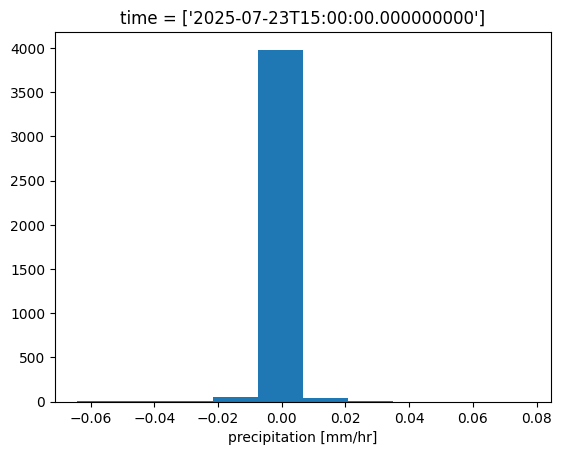

In [89]:
(model_prediction['precipitation'] - truth_ds['precipitation']).plot.hist()

In [ ]:
plot_kwargs = {'cmap':'viridis', 'vmin':0.0, 'vmax':5.0}

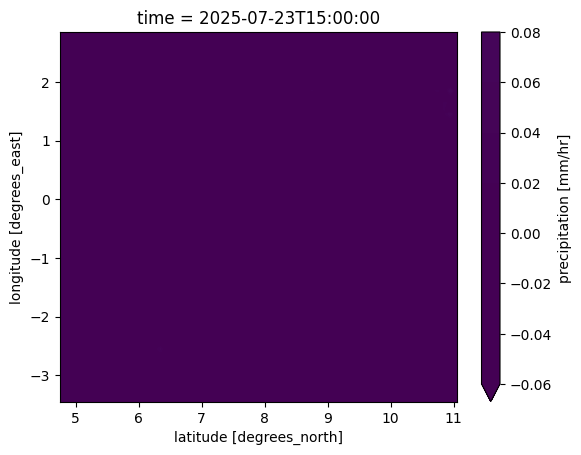

In [95]:
(model_prediction['precipitation'] - truth_ds['precipitation'])[0].plot.contourf(**plot_kwargs)

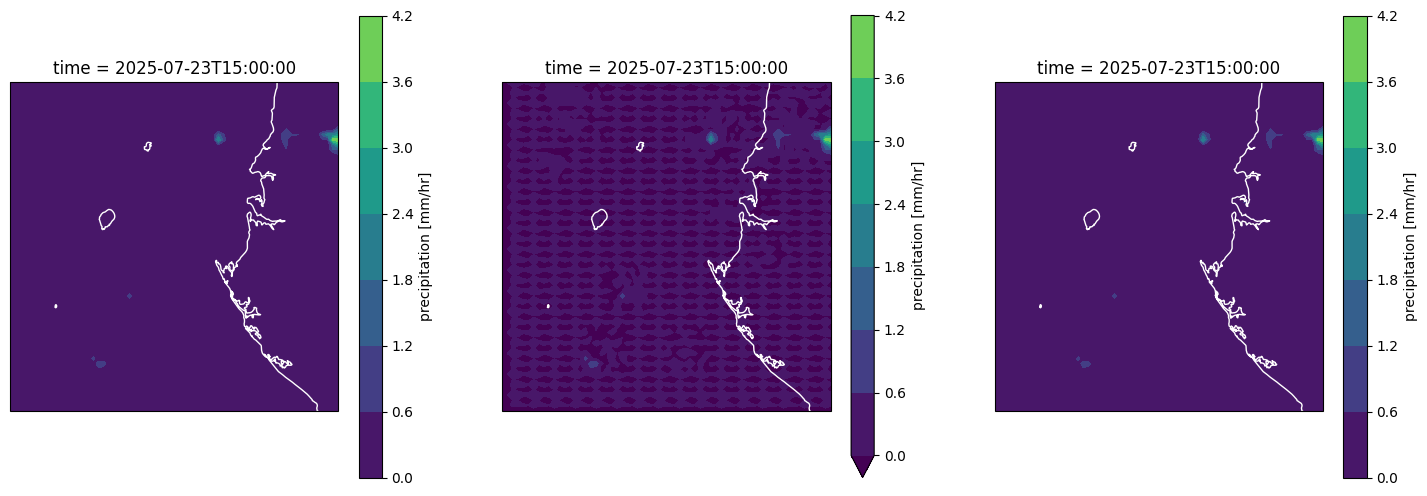

In [97]:
fig1 = matplotlib.pyplot.figure(figsize=(18,6))

ax1=fig1.add_subplot(1,3,1,projection=cartopy.crs.PlateCarree())
input_ds['precipitation'][0].plot.contourf(ax=ax1, **plot_kwargs)
ax1.coastlines(color='w')

ax1=fig1.add_subplot(1,3,2,projection=cartopy.crs.PlateCarree())
model_prediction['precipitation'][0].plot.contourf(ax=ax1, **plot_kwargs)
ax1.coastlines(color='w')


ax1=fig1.add_subplot(1,3,3,projection=cartopy.crs.PlateCarree())
truth_ds['precipitation'][0].plot.contourf(ax=ax1, **plot_kwargs)
ax1.coastlines(color='w')
